# 05 — C-MAPSS Anomaly-Triggered IPMEF Updated

This notebook evaluates whether an anomaly-detection stage can trigger RUL prediction selectively while preserving critical-failure coverage and reducing unnecessary downstream inference.

## Research contribution

The notebook extends the deployment-oriented evaluation methodology from model-level evaluation to **pipeline-level evaluation**:

```text
Temporal sensor window
        ↓
Anomaly detector
        ↓
Trigger decision
        ↓
RUL model invoked only when required
        ↓
Maintenance-oriented output
```

## Research-question alignment

- **RQ1:** determines whether adding anomaly-triggered inference changes the interpretation and selection of the best RUL deployment pipeline relative to always-on inference.
- **RQ2:** evaluates detector and pipeline robustness under controlled temporal sensor corruptions.
- **RQ3:** balances RUL prediction quality, critical-window coverage, invocation reduction, latency and missed-critical risk through Pareto and constraint-based selection.

## Important interpretation boundaries

- C-MAPSS supports temporal anomaly-triggered RUL inference, not multi-class fault-phenotype classification.
- A “critical” window is operationally defined by capped RUL at or below `CRITICAL_RUL_MAX`.
- Thresholds are selected on validation windows only.
- Detector penalties are assumed decision penalties, not monetary costs.
- Test-engine labels are used only for final evaluation.

In [ ]:
# Install required package
!pip -q install numpy pandas matplotlib scipy scikit-learn tensorflow joblib statsmodels

In [ ]:
# Import libraries
import os, sys, json, time, random, platform, warnings
from pathlib import Path
import joblib, psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Scikit-learn utilities
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

In [ ]:
# Base directories for Notebook 4 outputs
BASE = Path("cmapss_rul_ipmef_outputs")
PROCESSED = BASE / "processed"
MODEL_DIR = BASE / "models"

# Output directories for Notebook 5
OUT = Path("cmapss_anomaly_triggered_ipmef_outputs")
FIG = OUT / "figures"
DET_MODEL_DIR = OUT / "models"

# Ensure directories exist
for directory in [OUT, FIG, DET_MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Experiment constants
SEED = 42
RUL_CAP = 125.0

HEALTHY_RUL_MIN = 100.0
WARNING_RUL_MAX = 60.0
CRITICAL_RUL_MAX = 30.0

FALSE_TRIGGER_PENALTY = 1.0
MISSED_CRITICAL_PENALTY = 20.0

BOOTSTRAP_SAMPLES = 5000
CORRUPTION_REPEATS = 5

LATENCY_WARMUPS = 5
LATENCY_REPEATS = 30

PERIODIC_SAFEGUARDS = [5, 10, 20]

# Deterministic seed setup
set_global_seed_available = hasattr(tf.keras.utils, "set_random_seed")

def set_global_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    if set_global_seed_available:
        tf.keras.utils.set_random_seed(seed)

    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass

set_global_seed(SEED)

print("Output directory:", OUT.resolve())

Output directory: /content/cmapss_anomaly_triggered_ipmef_outputs


In [ ]:
# Validate and load Notebook 4 outputs
required_files = {
    "sequences": PROCESSED / "fd001_primary_sequences.npz",
    "manifest": PROCESSED / "notebook5_handoff_manifest.json",
    "candidate_summary": BASE / "06_candidate_summary.csv",
    "clean_results": BASE / "01_clean_results.csv",
    "test_predictions": BASE / "01b_test_predictions_and_residuals.csv",
    "test_metadata": PROCESSED / "fd001_test_window_metadata.csv",
    "validation_metadata": PROCESSED / "fd001_validation_window_metadata.csv",
}

# Check for missing files
missing_files = [
    str(path)
    for path in required_files.values()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Required Notebook 4 outputs were not found:\n"
        + "\n".join(missing_files)
    )

# Load handoff manifest
with open(required_files["manifest"], "r", encoding="utf-8") as file:
    handoff_manifest = json.load(file)

# Load temporal windows
sequence_data = np.load(required_files["sequences"])

Xtr = sequence_data["Xtr"].astype(np.float32)
ytr = sequence_data["ytr"].astype(np.float32)

Xv = sequence_data["Xv"].astype(np.float32)
yv = sequence_data["yv"].astype(np.float32)

Xte = sequence_data["Xte"].astype(np.float32)
yte = sequence_data["yte"].astype(np.float32)

# Load Notebook 4 tables
candidate_summary = pd.read_csv(required_files["candidate_summary"])
clean_results = pd.read_csv(required_files["clean_results"])
test_prediction_table = pd.read_csv(required_files["test_predictions"])


# Load metadata
test_metadata = pd.read_csv(required_files["test_metadata"])
validation_metadata = pd.read_csv(required_files["validation_metadata"])

# Sanity checks
assert len(Xte) == len(yte)
assert len(test_metadata) == len(yte)
assert len(validation_metadata) == len(yv)

print("Xtr:", Xtr.shape, "ytr:", ytr.shape)
print("Xv:", Xv.shape, "yv:", yv.shape)
print("Xte:", Xte.shape, "yte:", yte.shape)
display(candidate_summary.head())

Xtr: (14459, 30, 17) ytr: (14459,)
Xv: (3272, 30, 17) yv: (3272,)
Xte: (100, 30, 17) yte: (100,)


,Model,Training_Time_Seconds,Epochs_Trained,Model_Size_MB,Batch_Latency_Median_ms,Batch_Latency_P95_ms,Latency_Per_Sample_Median_ms,Throughput_Samples_Per_Second,Single_Sample_Latency_Median_ms,Single_Sample_Latency_P95_ms,...,MAE_Rank,NASA_Score_Rank,Conventional_Mean_Rank,Conventional_Rank,Predictive_Score,Robustness_Score,Efficiency_Score,Deployment_Baseline_Score,Deployment_Baseline_Rank,Rank_Change_Deployment_Minus_Conventional
0,Random Forest,486.389331,NaN,197.846559,148.736705,152.021442,1.487367,672.329001,140.937667,152.681506,...,1.0,1.0,1.000000,1,1.000000,0.184153,0.000000,0.394718,4,3
1,XGBoost,2.770726,NaN,0.515448,1.614822,1.755478,0.016148,61926.329962,0.684253,2.792220,...,2.0,2.0,2.000000,2,0.955677,0.527053,0.997179,0.826636,1,-1
2,GRU,30.258009,32.0,0.236370,116.901450,141.192949,1.169015,855.421383,74.589205,82.942907,...,4.0,3.0,3.333333,3,0.575284,0.684778,0.735216,0.665093,3,0
3,LSTM,20.090268,19.0,0.294238,115.554157,140.328476,1.155542,865.395093,73.595436,88.338198,...,3.0,4.0,3.666667,4,0.554694,1.000000,0.738602,0.764432,2,-2
4,Ridge,0.083586,NaN,0.000783,0.840750,1.088665,0.008407,118941.421357,0.256516,0.316908,...,5.0,5.0,5.000000,5,0.000000,0.000000,1.000000,0.333333,5,0


In [ ]:
# Record environment metadata
environment = {
    "python_version": sys.version,
    "platform": platform.platform(),
    "processor": platform.processor(),
    "logical_cpu_count": psutil.cpu_count(logical=True),
    "physical_cpu_count": psutil.cpu_count(logical=False),
    "ram_gb": round(psutil.virtual_memory().total / (1024 ** 3), 2),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "tensorflow_version": tf.__version__,
}

experiment_configuration = {
    "seed": SEED,
    "healthy_rul_min": HEALTHY_RUL_MIN,
    "warning_rul_max": WARNING_RUL_MAX,
    "critical_rul_max": CRITICAL_RUL_MAX,
    "false_trigger_penalty": FALSE_TRIGGER_PENALTY,
    "missed_critical_penalty": MISSED_CRITICAL_PENALTY,
    "bootstrap_samples": BOOTSTRAP_SAMPLES,
    "corruption_repeats": CORRUPTION_REPEATS,
    "periodic_safeguards": PERIODIC_SAFEGUARDS,
    "interpretation": {
        "critical_definition": (
            "A window is critical when capped RUL is at or below "
            f"{CRITICAL_RUL_MAX}."
        ),
        "detector_cost": (
            "False-trigger and missed-critical penalties are assumed "
            "decision penalties, not monetary costs."
        ),
        "pipeline_scope": (
            "Anomaly-triggered RUL inference, not multi-class fault diagnosis."
        ),
    },
}

# Save metadata
with open(OUT / "execution_environment.json", "w", encoding="utf-8") as file:
    json.dump(environment, file, indent=2)

with open(OUT / "experiment_configuration.json", "w", encoding="utf-8") as file:
    json.dump(experiment_configuration, file, indent=2)

display(pd.DataFrame([environment]).T.rename(columns={0: "Value"}))

,Value
python_version,"3.12.13 (main, Mar 4 2026, 09:23:07) [GCC 11...."
platform,Linux-6.6.122+-x86_64-with-glibc2.35
processor,x86_64
logical_cpu_count,2
physical_cpu_count,1
ram_gb,12.67
numpy_version,2.0.2
pandas_version,2.2.2
tensorflow_version,2.20.0


## Select and Load the Downstream RUL Model

This section loads the RUL model selected in Notebook 4 for downstream inference.

The anomaly‑triggered pipeline requires a **single downstream RUL model** that is
invoked only when the detector triggers. The selection rule is:

1. Prefer the **deployment‑oriented baseline winner** from Notebook 4  
   (highest Deployment Baseline Score).

2. If the deployment‑oriented ranking is unavailable, fall back to the  
   **lowest‑RMSE model** from the clean baseline.

The section then:
- loads the saved model (.joblib),
- constructs the correct prediction function,
- computes the always‑on baseline predictions for comparison,
- and prints the selected model name and type.


In [ ]:
# Select downstream model
if "Deployment_Baseline_Rank" in candidate_summary.columns:
    # Preferred: deployment-oriented winner
    downstream_model_name = (
        candidate_summary
        .sort_values("Deployment_Baseline_Rank")
        .iloc[0]["Model"]
    )
else:
    # Fallback: lowest RMSE model
    downstream_model_name = (
        clean_results
        .sort_values("RMSE")
        .iloc[0]["Model"]
    )

# Sequence summary function (for classical models)
def sequence_summary(X):
    """
    Compute tabular summary features for classical regression models:
        • mean over time
        • std over time
        • last timestep values
        • slope over time (per feature)
    """
    _, time_steps, _ = X.shape

    time_index = np.arange(time_steps, dtype=np.float32)
    centred_time = time_index - time_index.mean()

    denominator = (centred_time ** 2).sum()

    # slope per feature: regression of feature values over time
    slope = np.einsum(
        "t, ntf->nf",
        centred_time,
        X - X.mean(axis=1, keepdims=True),
    ) / denominator

    return np.c_[
        X.mean(axis=1),
        X.std(axis=1),
        X[:, -1, :],
        slope,
    ].astype(np.float32)

# Load downstream model
def load_downstream_model(model_name):
    safe_name = model_name.replace(" ", "_")

    joblib_path = MODEL_DIR / f"{safe_name}.joblib"
    keras_path = MODEL_DIR / f"{safe_name}.keras"

    # Classical model (joblib)
    if joblib_path.exists():
        loaded_model = joblib.load(joblib_path)

        def prediction_function(X_input):
            return np.asarray(
                loaded_model.predict(sequence_summary(X_input))
            ).reshape(-1)

        return loaded_model, "tabular_summary", prediction_function

    # Deep model (keras)
    if keras_path.exists():
        loaded_model = tf.keras.models.load_model(keras_path)

        def prediction_function(X_input):
            return (
                loaded_model.predict(X_input, verbose=0)
                .reshape(-1)
            )

        return loaded_model, "sequence", prediction_function

    # Neither model found
    raise FileNotFoundError(
        f"No saved model was found for {model_name}. "
        f"Expected {joblib_path} or {keras_path}."
    )


# Load selected model
downstream_model, downstream_model_type, downstream_predict = (
    load_downstream_model(downstream_model_name)
)

# Always-on baseline prediction
always_on_prediction = np.clip(
    downstream_predict(Xte),
    0,
    RUL_CAP,
)

print("Downstream RUL model:", downstream_model_name)
print("Model type:", downstream_model_type)

Downstream RUL model: XGBoost
Model type: tabular_summary


## Detector Definitions

This section defines the anomaly‑detection stage of the pipeline.  
Three detector configurations are evaluated:

1. **Isolation Forest**  
   A classical anomaly detector operating on tabular sequence‑summary features.

2. **LSTM Autoencoder**  
   A reconstruction‑based anomaly detector trained on healthy windows only.

3. **Hybrid Normalised Score**  
   A combined anomaly score that averages robustly normalised Isolation Forest and
   autoencoder scores.

All detectors are trained **only on healthy training windows**, defined as windows
with capped RUL ≥ HEALTHY_RUL_MIN.  
Validation windows with healthy labels are used to compute robust score
normalisation parameters (median + MAD scaling).

This section produces:
- trained Isolation Forest model  
- trained LSTM autoencoder  
- normalisation transforms  
- hybrid scores  
- detector timing metadata  


In [ ]:
# Identify healthy windows for detector training
healthy_training_mask = (ytr >= HEALTHY_RUL_MIN)
healthy_validation_mask = (yv >= HEALTHY_RUL_MIN)

healthy_training_windows = Xtr[healthy_training_mask]
healthy_validation_windows = Xv[healthy_validation_mask]

if len(healthy_training_windows) == 0:
    raise RuntimeError("No healthy training windows were found.")

if len(healthy_validation_windows) == 0:
    raise RuntimeError("No healthy validation windows were found.")

print("Healthy training windows:", len(healthy_training_windows))
print("Healthy validation windows:", len(healthy_validation_windows))

Healthy training windows: 6460
Healthy validation windows: 1272


In [ ]:
# Isolation Forest detector
isolation_model = IsolationForest(
    n_estimators=400,
    contamination="auto",
    random_state=SEED,
    n_jobs=-1,
)

isolation_training_start = time.perf_counter()

# Train on tabular sequence summaries
isolation_model.fit(sequence_summary(healthy_training_windows))

isolation_training_time = time.perf_counter() - isolation_training_start

def isolation_score(X_input):
    """
    Isolation Forest anomaly score.
    Higher values = more anomalous.
    """
    return -isolation_model.score_samples(sequence_summary(X_input))

# Save detector
joblib.dump(isolation_model, DET_MODEL_DIR / "isolation_forest.joblib")

['cmapss_anomaly_triggered_ipmef_outputs/models/isolation_forest.joblib']

In [ ]:
# LSTM Autoencoder detector
def build_autoencoder(input_shape):
    """
    Build a simple LSTM autoencoder:
        • LSTM encoder (48 units)
        • RepeatVector
        • LSTM decoder (48 units)
        • TimeDistributed Dense reconstruction
    """
    input_layer = layers.Input(shape=input_shape)

    encoded = layers.LSTM(48)(input_layer)
    repeated = layers.RepeatVector(input_shape[0])(encoded)
    decoded = layers.LSTM(48, return_sequences=True)(repeated)

    output_layer = layers.TimeDistributed(
        layers.Dense(input_shape[1])
    )(decoded)

    model = models.Model(input_layer, output_layer)
    model.compile(optimizer="adam", loss="mse")
    return model

# Reset TF session for reproducibility
tf.keras.backend.clear_session()
set_global_seed(SEED)

autoencoder = build_autoencoder(Xtr.shape[1:])

early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

reduce_learning_rate = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

autoencoder_training_start = time.perf_counter()

autoencoder_history = autoencoder.fit(
    healthy_training_windows,
    healthy_training_windows,
    validation_data=(healthy_validation_windows, healthy_validation_windows),
    epochs=50,
    batch_size=128,
    verbose=0,
    callbacks=[early_stopping, reduce_learning_rate],
)

autoencoder_training_time = time.perf_counter() - autoencoder_training_start

# Save autoencoder
autoencoder.save(
    DET_MODEL_DIR / "lstm_autoencoder.keras"
)

def autoencoder_score(X_input):
    """
    Autoencoder anomaly score = reconstruction error.
    Higher values = more anomalous.
    """
    reconstruction = autoencoder.predict(X_input, verbose=0)
    return np.mean((X_input - reconstruction) ** 2, axis=(1, 2))

## Validation-Based Score Normalisation and Threshold Selection

This section calibrates each anomaly detector using validation windows.

The process has three stages:

#### **Robust score normalisation**
Raw anomaly scores from the Isolation Forest and LSTM autoencoder are normalised using:
- **median**  
- **MAD (median absolute deviation)**  

This produces robust, scale‑free scores suitable for threshold selection.

#### **Hybrid anomaly score**
The hybrid detector averages the normalised Isolation Forest and autoencoder scores: Hybrid = 0.5 × Normalised_IF + 0.5 × Normalised_AE


#### **Threshold search**
Thresholds are selected by minimising the assumed detector penalty: Penalty = 1 × False Trigger + 20 × Missed Critical


Tie‑breaking criteria:
1. Higher recall  
2. Higher F1  
3. Lower trigger rate  

The result is:
- a selected threshold for each detector  
- a CSV table of all threshold candidates  
- a summary table of the best threshold per detector  


In [ ]:
# Compute validation scores
validation_isolation_scores = isolation_score(Xv)
validation_autoencoder_scores = autoencoder_score(Xv)

# Critical windows (for threshold optimisation)
critical_validation_target = (yv <= CRITICAL_RUL_MAX).astype(int)

# Robust score normalisation (median + MAD)
def robust_score_normaliser(reference_scores):
    """
    Robust normalisation using:
        location = median
        scale    = 1.4826 × MAD
    Normalised score = (score - median) / scale
    """
    reference_scores = np.asarray(reference_scores, dtype=float)

    location = float(np.median(reference_scores))
    mad = float(np.median(np.abs(reference_scores - location)))

    scale = max(1.4826 * mad, 1e-12)  # avoid divide-by-zero

    def transform(scores):
        return (np.asarray(scores, dtype=float) - location) / scale

    return transform, {"median": location, "robust_scale": scale}

# Normalise using healthy validation windows only
normalise_isolation, isolation_normalisation = robust_score_normaliser(
    validation_isolation_scores[healthy_validation_mask]
)

normalise_autoencoder, autoencoder_normalisation = robust_score_normaliser(
    validation_autoencoder_scores[healthy_validation_mask]
)

# Hybrid anomaly score (average of normalised scores)
validation_hybrid_scores = (
    0.5 * normalise_isolation(validation_isolation_scores)
    + 0.5 * normalise_autoencoder(validation_autoencoder_scores)
)

# Detector metrics for a given threshold
def detector_metrics(target, scores, threshold):
    """
    Compute precision, recall, F1, trigger rate, false-trigger rate,
    missed-critical rate, and detector penalty.
    """
    prediction = (np.asarray(scores) >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        target,
        prediction,
        labels=[0, 1],
    ).ravel()

    detector_penalty = (
        FALSE_TRIGGER_PENALTY * fp
        + MISSED_CRITICAL_PENALTY * fn
    )

    return {
        "Precision": precision_score(target, prediction, zero_division=0),
        "Recall": recall_score(target, prediction, zero_division=0),
        "F1": f1_score(target, prediction, zero_division=0),
        "Trigger_Rate": float(prediction.mean()),
        "Invocation_Reduction": float(1.0 - prediction.mean()),
        "False_Trigger_Rate": float(fp / max(fp + tn, 1)),
        "Missed_Critical_Rate": float(fn / max(fn + tp, 1)),
        "Detector_Penalty": float(detector_penalty),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }

# Threshold search
def threshold_search(detector_name, scores, target):
    """
    Evaluate 500 quantile-based thresholds.
    Select threshold with:
        1. lowest penalty
        2. highest recall
        3. highest F1
        4. lowest trigger rate
    """
    scores = np.asarray(scores, dtype=float)

    quantiles = np.unique(
        np.quantile(scores, np.linspace(0.01, 0.999, 500))
    )

    rows = []

    for threshold in quantiles:
        result = detector_metrics(target, scores, threshold)
        rows.append({
            "Detector": detector_name,
            "Threshold": float(threshold),
            **result,
        })

    table = pd.DataFrame(rows)

    best = (
        table.sort_values(
            ["Detector_Penalty", "Recall", "F1", "Trigger_Rate"],
            ascending=[True, False, False, True],
        )
        .iloc[0]
    )

    return float(best["Threshold"]), table

# Apply threshold search to all detectors
detector_score_map_validation = {
    "Isolation Forest": validation_isolation_scores,
    "LSTM Autoencoder": validation_autoencoder_scores,
    "Hybrid Detector": validation_hybrid_scores,
}

threshold_rows = []
selected_thresholds = {}

for detector_name, scores in detector_score_map_validation.items():
    threshold, table = threshold_search(
        detector_name,
        scores,
        critical_validation_target,
    )

    selected_thresholds[detector_name] = threshold

    # Save full threshold table
    table.to_csv(
        OUT / (
            "threshold_search_"
            + detector_name.lower().replace(" ", "_")
            + ".csv"
        ),
        index=False,
    )

    # Extract best row
    best_row = (
        table[table["Threshold"] == threshold]
        .iloc[0]
        .to_dict()
    )
    threshold_rows.append(best_row)

# Selected threshold summary table
selected_threshold_table.to_csv(
    OUT / "01_selected_detector_thresholds.csv",
    index=False,
)

display(selected_threshold_table)

,Detector,Threshold,Precision,Recall,F1,Trigger_Rate,Invocation_Reduction,False_Trigger_Rate,Missed_Critical_Rate,Detector_Penalty,TN,FP,FN,TP
0,Isolation Forest,0.531930,0.679558,0.991935,0.806557,0.276589,0.723411,0.109351,0.008065,390.0,2362,290,5,615
1,LSTM Autoencoder,0.330178,0.322390,0.966129,0.483454,0.567848,0.432152,0.474736,0.033871,1679.0,1393,1259,21,599
2,Hybrid Detector,2.192263,0.679287,0.983871,0.803689,0.274450,0.725550,0.108597,0.016129,488.0,2364,288,10,610


## Validation Trajectory Coverage

This section evaluates how each detector behaves across **different RUL regimes** on the
validation set:

- **Critical windows**: capped RUL ≤ CRITICAL_RUL_MAX
- **Warning windows**: CRITICAL_RUL_MAX < capped RUL ≤ WARNING_RUL_MAX  
- **Normal windows**: capped RUL > WARNING_RUL_MAX

For each detector and its selected threshold, the following metrics are computed:

- **Trigger Rate** — proportion of windows where the detector fires  
- **Invocation Reduction** — proportion of windows where RUL inference is *not* invoked  
- **Critical Coverage** — proportion of critical windows correctly triggered  
- **Warning Coverage** — proportion of warning windows triggered  
- **False Trigger Normal** — proportion of normal windows incorrectly triggered  

This analysis answers key supervisor questions:

- Does anomaly detection reduce unnecessary computation?  
- Does it preserve critical‑failure coverage?  
- Does it introduce false triggers in healthy regimes?  

The results are saved to 02_validation_trajectory_coverage.csv.


In [ ]:
def trajectory_coverage(detector_name, scores, threshold):
    """
    Compute coverage metrics for a given detector and threshold:
        • Trigger rate
        • Invocation reduction
        • Critical coverage
        • Warning coverage
        • False-trigger rate on normal windows
    """
    trigger = (np.asarray(scores) >= threshold)

    # Window regime masks
    critical_mask = (yv <= CRITICAL_RUL_MAX)
    warning_mask = ((yv > CRITICAL_RUL_MAX) & (yv <= WARNING_RUL_MAX))
    normal_mask = (yv > WARNING_RUL_MAX)

    return {
        "Detector": detector_name,
        "Trigger_Rate": float(trigger.mean()),
        "Invocation_Reduction": float(1.0 - trigger.mean()),
        "Critical_Coverage": (
            float(trigger[critical_mask].mean())
            if critical_mask.any()
            else np.nan
        ),
        "Warning_Coverage": (
            float(trigger[warning_mask].mean())
            if warning_mask.any()
            else np.nan
        ),
        "False_Trigger_Normal": (
            float(trigger[normal_mask].mean())
            if normal_mask.any()
            else np.nan
        ),
    }

# Compute coverage for all detectors
coverage_rows = []

for detector_name, scores in detector_score_map_validation.items():
    coverage_rows.append(
        trajectory_coverage(
            detector_name,
            scores,
            selected_thresholds[detector_name],
        )
    )

validation_coverage = pd.DataFrame(coverage_rows)

validation_coverage.to_csv(
    OUT / "02_validation_trajectory_coverage.csv",
    index=False,
)

display(validation_coverage)

,Detector,Trigger_Rate,Invocation_Reduction,Critical_Coverage,Warning_Coverage,False_Trigger_Normal
0,Isolation Forest,0.276589,0.723411,0.991935,0.465000,0.005361
1,LSTM Autoencoder,0.567848,0.432152,0.966129,0.488333,0.470760
2,Hybrid Detector,0.274450,0.725550,0.983871,0.326667,0.044834


### Full Pipeline Evaluation Code

This section contains the complete implementation of:

- latency benchmarking  
- detector scoring on test windows  
- trigger mask construction  
- gated pipeline evaluation  
- always‑on baseline evaluation  
- periodic safeguard evaluation  
- final pipeline comparison table  

This is the operational core of Notebook 5, producing the full set of pipeline‑level
metrics used in RQ1, RQ2, and RQ3.


In [ ]:
# Latency benchmarking
def benchmark_function(function, X_input):
    """
    Benchmark median and P95 latency for a given function.
    Includes warm-up iterations to stabilise timing.
    """
    # Warm-up iterations
    for _ in range(LATENCY_WARMUPS):
        _ = function(X_input)

    timings = []

    # Timed iterations
    for _ in range(LATENCY_REPEATS):
        start = time.perf_counter()
        _ = function(X_input)
        timings.append(time.perf_counter() - start)

    timings = np.asarray(timings, dtype=float)

    return {
        "Median_Total_Time_Seconds": float(np.median(timings)),
        "P95_Total_Time_Seconds": float(np.quantile(timings, 0.95)),
    }

# Detector scores on test windows
test_isolation_scores = isolation_score(Xte)
test_autoencoder_scores = autoencoder_score(Xte)

test_hybrid_scores = (
    0.5 * normalise_isolation(test_isolation_scores)
    + 0.5 * normalise_autoencoder(test_autoencoder_scores)
)

detector_score_map_test = {
    "Isolation Forest": test_isolation_scores,
    "LSTM Autoencoder": test_autoencoder_scores,
    "Hybrid Detector": test_hybrid_scores,
}

# Regression metrics (RMSE, MAE)
def regression_metrics(y_true, y_prediction):
    """
    Compute RMSE and MAE for pipeline predictions.
    """
    y_prediction = np.clip(np.asarray(y_prediction, dtype=float), 0, RUL_CAP)

    return {
        "RMSE": float(mean_squared_error(y_true, y_prediction) ** 0.5),
        "MAE": float(mean_absolute_error(y_true, y_prediction)),
    }

# Trigger mask construction
def build_trigger_mask(scores, threshold, periodic=None):
    """
    Build binary trigger mask:
        • scores >= threshold
        • optional periodic safeguard forces trigger every k windows
    """
    trigger = (np.asarray(scores) >= threshold).copy()

    if periodic is not None:
        trigger[np.arange(0, len(trigger), periodic)] = True

    return trigger

# Evaluate gated pipeline
def evaluate_gated_pipeline(pipeline_name, detector_name, scores, threshold, periodic=None):
    """
    Evaluate a gated pipeline:
        • Build trigger mask
        • Produce predictions (default RUL_CAP when not triggered)
        • Compute regression metrics
        • Compute detector metrics
        • Benchmark latency (detector + downstream model)
    """
    trigger = build_trigger_mask(scores, threshold, periodic)

    # Default prediction for non-triggered windows
    output_prediction = np.full(len(yte), RUL_CAP, dtype=float)

    # Invoke downstream model only for triggered windows
    if trigger.any():
        output_prediction[trigger] = np.clip(
            downstream_predict(Xte[trigger]),
            0,
            RUL_CAP,
        )

    # Regression metrics
    pipeline_metrics = regression_metrics(yte, output_prediction)

    # Detector-level metrics
    critical_mask = (yte <= CRITICAL_RUL_MAX)
    detector_prediction = trigger.astype(int)
    detector_target = critical_mask.astype(int)

    detector_result = detector_metrics(
        detector_target,
        detector_prediction,
        threshold=0.5,  # binary threshold for confusion matrix
    )

    # Detector timing
    detector_function = {
        "Isolation Forest": isolation_score,
        "LSTM Autoencoder": autoencoder_score,
        "Hybrid Detector": lambda X_input: (
            0.5 * normalise_isolation(isolation_score(X_input))
            + 0.5 * normalise_autoencoder(autoencoder_score(X_input))
        ),
    }[detector_name]

    detector_timing = benchmark_function(detector_function, Xte)

    # Downstream timing (only for triggered windows)
    if trigger.any():
        downstream_timing = benchmark_function(
            downstream_predict,
            Xte[trigger],
        )
    else:
        downstream_timing = {
            "Median_Total_Time_Seconds": 0.0,
            "P95_Total_Time_Seconds": 0.0,
        }

    # Total latency
    estimated_median_latency = (
        detector_timing["Median_Total_Time_Seconds"]
        + downstream_timing["Median_Total_Time_Seconds"]
    )
    estimated_p95_latency = (
        detector_timing["P95_Total_Time_Seconds"]
        + downstream_timing["P95_Total_Time_Seconds"]
    )

    return {
        "Pipeline": pipeline_name,
        "Detector": detector_name,
        "Threshold": threshold,
        "Periodic_Safeguard": periodic,
        **pipeline_metrics,
        "Trigger_Rate": float(trigger.mean()),
        "Invocation_Reduction": float(1.0 - trigger.mean()),
        "Critical_Coverage": (
            float(trigger[critical_mask].mean())
            if critical_mask.any()
            else np.nan
        ),
        "Missed_Critical_Rate": (
            float((~trigger[critical_mask]).mean())
            if critical_mask.any()
            else np.nan
        ),
        "False_Trigger_Rate": detector_result["False_Trigger_Rate"],
        "Detector_Penalty": detector_result["Detector_Penalty"],
        "Estimated_Median_Total_Latency_s": float(estimated_median_latency),
        "Estimated_P95_Total_Latency_s": float(estimated_p95_latency),
    }

# Always-on baseline pipeline
always_on_timing = benchmark_function(downstream_predict, Xte)

pipeline_rows = [
    {
        "Pipeline": "Always-on RUL inference",
        "Detector": "None",
        "Threshold": np.nan,
        "Periodic_Safeguard": np.nan,
        **regression_metrics(yte, always_on_prediction),
        "Trigger_Rate": 1.0,
        "Invocation_Reduction": 0.0,
        "Critical_Coverage": 1.0,
        "Missed_Critical_Rate": 0.0,
        "False_Trigger_Rate": 1.0,
        "Detector_Penalty": float((~(yte <= CRITICAL_RUL_MAX)).sum()),
        "Estimated_Median_Total_Latency_s": always_on_timing["Median_Total_Time_Seconds"],
        "Estimated_P95_Total_Latency_s": always_on_timing["P95_Total_Time_Seconds"],
    }
]

# Gated pipelines (with and without periodic safeguards)
for detector_name, scores in detector_score_map_test.items():
    threshold = selected_thresholds[detector_name]

    # No periodic safeguard
    pipeline_rows.append(
        evaluate_gated_pipeline(
            f"{detector_name} gate",
            detector_name,
            scores,
            threshold,
            periodic=None,
        )
    )

    # With periodic safeguards
    for periodic in PERIODIC_SAFEGUARDS:
        pipeline_rows.append(
            evaluate_gated_pipeline(
                f"{detector_name} gate + periodic {periodic}",
                detector_name,
                scores,
                threshold,
                periodic=periodic,
            )
        )

# Final pipeline comparison table
pipeline_results = pd.DataFrame(pipeline_rows)

pipeline_results.to_csv(
    OUT / "03_pipeline_comparison.csv",
    index=False,
)

display(
    pipeline_results.sort_values(
        ["Missed_Critical_Rate", "RMSE", "Invocation_Reduction"],
        ascending=[True, True, False],
    )
)

,Pipeline,Detector,Threshold,Periodic_Safeguard,RMSE,MAE,Trigger_Rate,Invocation_Reduction,Critical_Coverage,Missed_Critical_Rate,False_Trigger_Rate,Detector_Penalty,Estimated_Median_Total_Latency_s,Estimated_P95_Total_Latency_s
0,Always-on RUL inference,None,NaN,NaN,12.143886,9.107116,1.00,0.00,1.00,0.00,1.000000,75.0,0.001505,0.001603
2,Isolation Forest gate + periodic 5,Isolation Forest,0.531930,5.0,27.284685,18.048068,0.43,0.57,1.00,0.00,0.240000,18.0,0.028157,0.032884
3,Isolation Forest gate + periodic 10,Isolation Forest,0.531930,10.0,27.918593,18.718113,0.38,0.62,1.00,0.00,0.173333,13.0,0.028498,0.035909
4,Isolation Forest gate + periodic 20,Isolation Forest,0.531930,20.0,28.042527,18.948667,0.35,0.65,1.00,0.00,0.133333,10.0,0.043336,0.063307
10,Hybrid Detector gate + periodic 5,Hybrid Detector,2.192263,5.0,28.262876,18.597003,0.45,0.55,1.00,0.00,0.266667,20.0,0.127254,0.149406
1,Isolation Forest gate,Isolation Forest,0.531930,NaN,28.879167,19.685305,0.33,0.67,1.00,0.00,0.106667,8.0,0.028354,0.033071
11,Hybrid Detector gate + periodic 10,Hybrid Detector,2.192263,10.0,29.910263,20.045700,0.39,0.61,1.00,0.00,0.186667,14.0,0.135069,0.207447
12,Hybrid Detector gate + periodic 20,Hybrid Detector,2.192263,20.0,30.025977,20.276254,0.36,0.64,1.00,0.00,0.146667,11.0,0.128130,0.140969
9,Hybrid Detector gate,Hybrid Detector,2.192263,NaN,30.808802,21.012891,0.34,0.66,1.00,0.00,0.120000,9.0,0.127563,0.143546
6,LSTM Autoencoder gate + periodic 5,LSTM Autoencoder,0.330178,5.0,31.682814,20.210377,0.57,0.43,0.92,0.08,0.453333,74.0,0.095229,0.103528


## Bootstrap Confidence Intervals for Pipeline Outcomes

This section quantifies uncertainty in pipeline‑level metrics using **bootstrap
resampling** of test windows.

Each bootstrap sample:
- resamples test windows with replacement,
- recomputes pipeline predictions,
- recomputes RMSE, MAE, trigger rate, invocation reduction, and missed‑critical rate.

This produces empirical distributions for each metric, from which:
- bootstrap mean  
- 95% confidence interval (CI95 low, CI95 high)  

are computed.

Bootstrap analysis is performed for:
- all detectors  
- all thresholds  
- all periodic safeguard configurations  

The results are saved to:
04_pipeline_bootstrap_confidence_intervals.csv.

This section supports RQ2 and RQ3 by quantifying stability and robustness of pipeline
behaviour under sampling variability.


In [ ]:
def bootstrap_pipeline_ci(scores, threshold, periodic, n_boot=BOOTSTRAP_SAMPLES, seed=SEED):
    """
    Compute bootstrap confidence intervals for a given pipeline configuration.
    Resamples test windows with replacement and recomputes:
        • RMSE
        • MAE
        • Trigger rate
        • Invocation reduction
        • Missed-critical rate
    """
    rng = np.random.default_rng(seed)

    # Build trigger mask for full test set
    trigger = build_trigger_mask(scores, threshold, periodic)

    # Default prediction for non-triggered windows
    output_prediction = np.full(len(yte), RUL_CAP, dtype=float)

    # Downstream predictions for triggered windows
    if trigger.any():
        output_prediction[trigger] = np.clip(
            downstream_predict(Xte[trigger]),
            0,
            RUL_CAP,
        )

    bootstrap_rows = []

    for _ in range(n_boot):
        # Resample indices
        indices = rng.choice(len(yte), size=len(yte), replace=True)

        y_sample = yte[indices]
        prediction_sample = output_prediction[indices]
        trigger_sample = trigger[indices]

        critical_sample = (y_sample <= CRITICAL_RUL_MAX)

        bootstrap_rows.append({
            "RMSE": float(mean_squared_error(y_sample, prediction_sample) ** 0.5),
            "MAE": float(mean_absolute_error(y_sample, prediction_sample)),
            "Trigger_Rate": float(trigger_sample.mean()),
            "Invocation_Reduction": float(1.0 - trigger_sample.mean()),
            "Missed_Critical_Rate": (
                float((~trigger_sample[critical_sample]).mean())
                if critical_sample.any()
                else np.nan
            ),
        })

    bootstrap_df = pd.DataFrame(bootstrap_rows)

    # Summarise bootstrap distributions
    summary_rows = []

    for metric in bootstrap_df.columns:
        valid_values = bootstrap_df[metric].dropna()

        summary_rows.append({
            "Metric": metric,
            "Bootstrap_Mean": float(valid_values.mean()),
            "CI95_Low": float(valid_values.quantile(0.025)),
            "CI95_High": float(valid_values.quantile(0.975)),
        })

    return pd.DataFrame(summary_rows)

# Compute bootstrap summaries for all pipelines
bootstrap_summary_rows = []

for detector_name, scores in detector_score_map_test.items():
    threshold = selected_thresholds[detector_name]

    for periodic in [
        None,
        *PERIODIC_SAFEGUARDS,
    ]:
        pipeline_name = (
            f"{detector_name} gate"
            if periodic is None
            else (
                f"{detector_name} gate "
                f"+ periodic {periodic}"
            )
        )

        summary = bootstrap_pipeline_ci(
            scores,
            threshold,
            periodic,
            seed=SEED + (0 if periodic is None else periodic),
        )

        summary.insert(0, "Pipeline", pipeline_name)

        bootstrap_summary_rows.append(summary)

# Combine and save bootstrap results
pipeline_bootstrap_summary = pd.concat(bootstrap_summary_rows, ignore_index=True)

pipeline_bootstrap_summary.to_csv(
    OUT / "04_pipeline_bootstrap_confidence_intervals.csv",
    index=False,
)

display(pipeline_bootstrap_summary)

,Pipeline,Metric,Bootstrap_Mean,CI95_Low,CI95_High
0,Isolation Forest gate,RMSE,28.800339,23.961793,33.492626
1,Isolation Forest gate,MAE,19.708583,15.599050,23.932163
2,Isolation Forest gate,Trigger_Rate,0.329190,0.240000,0.420000
3,Isolation Forest gate,Invocation_Reduction,0.670810,0.580000,0.760000
4,Isolation Forest gate,Missed_Critical_Rate,0.000000,0.000000,0.000000
5,Isolation Forest gate + periodic 5,RMSE,27.131478,22.139578,31.926437
6,Isolation Forest gate + periodic 5,MAE,18.018293,14.196963,22.062915
7,Isolation Forest gate + periodic 5,Trigger_Rate,0.431366,0.330000,0.530000
8,Isolation Forest gate + periodic 5,Invocation_Reduction,0.568634,0.470000,0.670000
9,Isolation Forest gate + periodic 5,Missed_Critical_Rate,0.000000,0.000000,0.000000


## Paired Statistical Comparison of Absolute Errors

This section evaluates whether gated pipelines produce statistically different absolute
RUL errors compared to **always‑on inference**.

The comparison uses the **Wilcoxon signed‑rank test**, a non‑parametric paired test
appropriate for comparing error distributions across the same test windows.

For each pipeline:

1. Compute absolute error for:
   - always‑on inference  
   - gated pipeline  

2. Compute paired differences: difference = |error_gated| − |error_always_on|


3. Apply the Wilcoxon signed‑rank test:
- statistic  
- p-value
- Holm‑adjusted p-value (multiple‑comparison correction)  
- significance flag  
- effect size (Cohen’s dz)  

4. Determine direction:
- **Lower absolute error than always‑on**  
- **Higher absolute error than always‑on**  
- **No mean difference**  

The results are saved to
05_pipeline_paired_wilcoxon_tests.csv.

This section supports RQ1 and RQ2 by quantifying whether anomaly‑triggered inference
changes predictive error behaviour relative to always‑on inference.


In [ ]:
# Always-on absolute error
always_on_absolute_error = np.abs(always_on_prediction - yte)

statistical_rows = []

# Evaluate each pipeline except always-on
for _, pipeline_row in (
    pipeline_results[pipeline_results["Pipeline"] != "Always-on RUL inference"].iterrows()
):

    detector_name = pipeline_row["Detector"]
    scores = detector_score_map_test[detector_name]

    # Determine periodic safeguard value
    periodic_value = (
        None
        if pd.isna(pipeline_row["Periodic_Safeguard"])
        else int(pipeline_row["Periodic_Safeguard"])
    )

    # Build trigger mask
    trigger = build_trigger_mask(
        scores,
        pipeline_row["Threshold"],
        periodic_value,
    )

    # Compute gated predictions
    gated_prediction = np.full(len(yte), RUL_CAP, dtype=float)

    if trigger.any():
        gated_prediction[trigger] = np.clip(
            downstream_predict(Xte[trigger]),
            0,
            RUL_CAP,
        )

    gated_absolute_error = np.abs(gated_prediction - yte)

    # Paired differences
    differences = gated_absolute_error - always_on_absolute_error

    # Handle degenerate case (all differences zero)
    if np.allclose(differences, 0):
        statistic = 0.0
        raw_p = 1.0
    else:
        statistic, raw_p = wilcoxon(
            gated_absolute_error,
            always_on_absolute_error,
            alternative="two-sided",
            method="auto",
        )

    # Effect size (Cohen's dz)
    difference_sd = differences.std(ddof=1)
    cohens_dz = (
        np.nan
        if np.isclose(difference_sd, 0)
        else float(differences.mean() / difference_sd)
    )

    statistical_rows.append({
        "Pipeline": pipeline_row["Pipeline"],
        "Comparison": "Gated absolute error vs always-on absolute error",
        "Mean_Difference_Gated_Minus_Always_On": float(differences.mean()),
        "Median_Difference_Gated_Minus_Always_On": float(np.median(differences)),
        "Cohens_dz": cohens_dz,
        "Wilcoxon_Statistic": float(statistic),
        "Raw_p": float(raw_p),
    })

# Build statistical comparison table
pipeline_tests = pd.DataFrame(statistical_rows)

# Holm correction for multiple comparisons
pipeline_tests["Holm_Adjusted_p"] = multipletests(
    pipeline_tests["Raw_p"],
    method="holm",
)[1]

# Significance flag
pipeline_tests["Significant_0.05"] = (
    pipeline_tests["Holm_Adjusted_p"] < 0.05
)

# Direction of difference
pipeline_tests["Direction"] = np.where(
    pipeline_tests["Mean_Difference_Gated_Minus_Always_On"] < 0,
    "Lower absolute error than always-on",
    np.where(
        pipeline_tests["Mean_Difference_Gated_Minus_Always_On"] > 0,
        "Higher absolute error than always-on",
        "No mean difference",
    ),
)

# Save results
pipeline_tests.to_csv(
    OUT / "05_pipeline_paired_wilcoxon_tests.csv",
    index=False,
)

display(pipeline_tests)

,Pipeline,Comparison,Mean_Difference_Gated_Minus_Always_On,Median_Difference_Gated_Minus_Always_On,Cohens_dz,Wilcoxon_Statistic,Raw_p,Holm_Adjusted_p,Significant_0.05,Direction
0,Isolation Forest gate,Gated absolute error vs always-on absolute error,10.578189,3.337273,0.540639,339.0,5.813358e-07,0.000005,True,Higher absolute error than always-on
1,Isolation Forest gate + periodic 5,Gated absolute error vs always-on absolute error,8.940952,0.000000,0.477626,258.0,6.276610e-06,0.000014,True,Higher absolute error than always-on
2,Isolation Forest gate + periodic 10,Gated absolute error vs always-on absolute error,9.610997,0.000000,0.507186,299.0,2.034146e-06,0.000008,True,Higher absolute error than always-on
3,Isolation Forest gate + periodic 20,Gated absolute error vs always-on absolute error,9.841551,2.513737,0.520992,330.0,1.221056e-06,0.000006,True,Higher absolute error than always-on
4,LSTM Autoencoder gate,Gated absolute error vs always-on absolute error,12.919624,0.000000,0.522725,114.0,4.338059e-07,0.000005,True,Higher absolute error than always-on
5,LSTM Autoencoder gate + periodic 5,Gated absolute error vs always-on absolute error,11.103261,0.000000,0.464693,98.0,5.951440e-06,0.000014,True,Higher absolute error than always-on
6,LSTM Autoencoder gate + periodic 10,Gated absolute error vs always-on absolute error,12.634041,0.000000,0.509417,98.0,8.169005e-07,0.000006,True,Higher absolute error than always-on
7,LSTM Autoencoder gate + periodic 20,Gated absolute error vs always-on absolute error,12.812534,0.000000,0.517704,109.0,5.486646e-07,0.000005,True,Higher absolute error than always-on
8,Hybrid Detector gate,Gated absolute error vs always-on absolute error,11.905776,3.337273,0.554168,299.0,2.577402e-07,0.000003,True,Higher absolute error than always-on
9,Hybrid Detector gate + periodic 5,Gated absolute error vs always-on absolute error,9.489887,0.000000,0.481872,224.0,4.769317e-06,0.000014,True,Higher absolute error than always-on


## RQ2 — Detector Robustness Under Temporal Corruptions

This section evaluates how each anomaly detector behaves when test windows are
corrupted using the same temporal corruption types introduced in Notebook 4.

The goal is to measure **detector robustness**, defined through:

- **Critical Coverage**  
  proportion of corrupted critical windows correctly triggered  

- **False Trigger Rate**  
  proportion of corrupted normal windows incorrectly triggered  

- **Trigger Rate Retention**  
  how much the detector’s trigger rate changes under corruption  

The corruption types include:
- Gaussian Noise  
- Missing Block  
- Outliers  
- Gradual Offset Drift  
- Sensor Freezing  

Each corruption type is applied at multiple severity levels.  
For each (detector, corruption type, severity level), the detector’s threshold is applied to corrupted windows, and robustness metrics are computed.

This section supports **RQ2** by quantifying how well anomaly detection maintains
critical‑failure coverage under degraded sensor conditions.


In [ ]:
# Corruption levels and identifiers
CORRUPTION_LEVELS = {
    "Gaussian_Noise": [0.05, 0.10, 0.20, 0.30],
    "Missing_Block": [0.05, 0.10, 0.20, 0.30],
    "Outliers": [0.01, 0.03, 0.05, 0.10],
    "Gradual_Offset_Drift": [0.05, 0.10, 0.20, 0.30],
    "Sensor_Freezing": [0.10, 0.20, 0.30, 0.40],
}

CONDITION_IDS = {
    condition: index
    for index, condition in enumerate(CORRUPTION_LEVELS, start=1)
}

# Corruption function
def corrupt_sequences(X_input, condition, level, rng):
    """
    Apply a temporal corruption to X_input:
        • Gaussian noise
        • Missing block
        • Outliers
        • Gradual offset drift
        • Sensor freezing
    """
    corrupted = X_input.copy()
    sample_count, time_steps, feature_count = corrupted.shape

    # Gaussian noise
    if condition == "Gaussian_Noise":
        corrupted += rng.normal(
            0.0,
            level,
            size=corrupted.shape,
        ).astype(np.float32)

    # Missing block
    elif condition == "Missing_Block":
        block_length = max(1, int(round(time_steps * level)))

        for sample_index in range(sample_count):
            feature_index = int(rng.integers(feature_count))
            start_index = int(
                rng.integers(0, max(1, time_steps - block_length + 1))
            )
            corrupted[
                sample_index,
                start_index:start_index + block_length,
                feature_index,
            ] = 0.0

    # Outliers
    elif condition == "Outliers":
        outlier_count = max(
            1,
            int(round(sample_count * time_steps * feature_count * level)),
        )

        flat = corrupted.reshape(-1)
        selected = rng.choice(len(flat), size=outlier_count, replace=False)

        flat[selected] += (
            rng.choice([-1.0, 1.0], size=outlier_count) * 4.0
        )
        corrupted = flat.reshape(corrupted.shape)

    # Gradual offset drift
    elif condition == "Gradual_Offset_Drift":
        selected_feature_count = max(1, feature_count // 4)
        selected_features = rng.choice(
            feature_count,
            size=selected_feature_count,
            replace=False,
        )

        drift = np.linspace(
            0.0,
            level * 3.0,
            time_steps,
            dtype=np.float32,
        )

        corrupted[:, :, selected_features] += drift[None, :, None]

    # Sensor freezing
    elif condition == "Sensor_Freezing":
        freeze_length = max(1, int(round(time_steps * level)))
        freeze_start = time_steps - freeze_length

        for sample_index in range(sample_count):
            feature_index = int(rng.integers(feature_count))
            frozen_value = corrupted[sample_index, freeze_start, feature_index]
            corrupted[sample_index, freeze_start:, feature_index] = frozen_value

    else:
        raise ValueError(f"Unsupported corruption: {condition}")

    return corrupted.astype(np.float32)

In [ ]:
# Robustness evaluation
detector_robustness_rows = []

clean_detector_metrics = {}

for detector_name, scores in (detector_score_map_test.items()):
    clean_detector_metrics[detector_name] = detector_metrics(
        (yte <= CRITICAL_RUL_MAX).astype(int),
        scores,
        selected_thresholds[detector_name],
    )

for condition, levels in CORRUPTION_LEVELS.items():
    for level in levels:

        for repeat in range(CORRUPTION_REPEATS):
            corruption_seed = (SEED * 1_000_000 + CONDITION_IDS[condition] * 100_000
                + repeat * 1_000
                + int(level* 10_000)
            )

            rng = np.random.default_rng(SEED)

            # Apply corruption
            corrupted_X = corrupt_sequences(Xte, condition, level, rng)

            # Compute corrupted scores
            corrupted_scores = {
                "Isolation Forest":
                    isolation_score(corrupted_X),
                "LSTM Autoencoder":
                    autoencoder_score(corrupted_X),
            }

            corrupted_scores["Hybrid Detector"] = (
                0.5 * normalise_isolation(corrupted_scores["Isolation Forest"])
                + 0.5 * normalise_autoencoder(corrupted_scores["LSTM Autoencoder"])
            )

            Masks
            for detector_name, scores in (corrupted_scores.items()):
                result = detector_metrics(
                    (
                        yte
                        <= CRITICAL_RUL_MAX
                    ).astype(int),
                    scores,
                    selected_thresholds[
                        detector_name
                    ],
                )

                clean_result = (clean_detector_metrics[detector_name])

                # Metrics
                detector_robustness_rows.append({
                        "Detector":detector_name,
                        "Condition":condition,
                        "Level":level,
                        "Repeat":repeat,
                        **result,
                        "Critical_Coverage_Retention":
                            (result["Recall"] / max(clean_result["Recall"], 1e-12)
                            ),
                        "F1_Retention":
                            (result["F1"] / max(clean_result["F1"], 1e-12)
                            ),
                        "Penalty_Inflation":
                            (result["Detector_Penalty"] / max(clean_result["Detector_Penalty"], 1e-12)
                            ),
                    }
                )

# Save robustness results
detector_robustness_raw = pd.DataFrame(detector_robustness_rows)

detector_robustness_raw.to_csv(
    OUT / "06_detector_robustness_raw.csv",
    index=False,
)

display(detector_robustness_raw.head())

,Detector,Condition,Level,Repeat,Precision,Recall,F1,Trigger_Rate,Invocation_Reduction,False_Trigger_Rate,Missed_Critical_Rate,Detector_Penalty,TN,FP,FN,TP,Critical_Coverage_Retention,F1_Retention,Penalty_Inflation
0,Isolation Forest,Gaussian_Noise,0.05,0,0.735294,1.00,0.847458,0.34,0.66,0.120000,0.00,9.0,66,9,0,25,1.0,0.983051,1.125000
1,LSTM Autoencoder,Gaussian_Noise,0.05,0,0.460000,0.92,0.613333,0.50,0.50,0.360000,0.08,67.0,48,27,2,23,1.0,1.000000,1.000000
2,Hybrid Detector,Gaussian_Noise,0.05,0,0.735294,1.00,0.847458,0.34,0.66,0.120000,0.00,9.0,66,9,0,25,1.0,1.000000,1.000000
3,Isolation Forest,Gaussian_Noise,0.05,1,0.735294,1.00,0.847458,0.34,0.66,0.120000,0.00,9.0,66,9,0,25,1.0,0.983051,1.125000
4,LSTM Autoencoder,Gaussian_Noise,0.05,1,0.450980,0.92,0.605263,0.51,0.49,0.373333,0.08,68.0,47,28,2,23,1.0,0.986842,1.014925


##  Detector Robustness Aggregation (AUC + Composite Scores)

This section aggregates detector‑level robustness results across corruption severity
levels and corruption types.  
It converts raw robustness metrics into **area‑under‑curve (AUC)** summaries and
composite robustness indicators.

The process has three stages:

#### **Aggregate robustness by corruption level**
For each detector × corruption type × severity level, compute:
- mean and std of critical coverage  
- mean and std of F1  
- mean trigger rate  
- mean false‑trigger rate  
- mean detector penalty  
- retention metrics (coverage retention, F1 retention, penalty inflation)

#### **Compute AUC robustness curves**
For each detector × corruption type:
- normalise severity to [0, 1]  
- prepend baseline (severity = 0, retention = 1)  
- compute AUC for:
  - critical‑coverage retention  
  - F1 retention  
  - penalty inflation  
- compute worst‑case retention

#### **Composite detector robustness**
Aggregate across corruption types to produce:
- Composite_Detector_Robustness  
- Composite_Detector_F1_Robustness  
- Mean_Detector_Penalty_Inflation_AUC  
- Worst_Condition_Coverage_Retention  

These composite metrics are used later in Section 11 and Section 12 for
pipeline‑level decision making.


In [ ]:
# Aggregate robustness by corruption level
detector_robustness_by_level = (
    detector_robustness_raw
    .groupby(
        ["Detector", "Condition", "Level"],
        as_index=False,
    )
    .agg(
        Critical_Coverage=("Recall", "mean"),
        Critical_Coverage_Std=("Recall", "std"),
        F1=("F1", "mean"),
        F1_Std=("F1", "std"),
        Trigger_Rate=("Trigger_Rate", "mean"),
        False_Trigger_Rate=("False_Trigger_Rate", "mean"),
        Detector_Penalty=("Detector_Penalty", "mean"),
        Critical_Coverage_Retention=("Critical_Coverage_Retention", "mean"),
        F1_Retention=("F1_Retention", "mean"),
        Penalty_Inflation=("Penalty_Inflation", "mean"),
    )
)

# Compute AUC robustness curves
detector_area_rows = []

for (detector_name, condition), group in (
    detector_robustness_by_level.groupby(["Detector", "Condition"])
):
    # Sort by severity level
    group = group.sort_values("Level")

    # Normalised severity: prepend baseline (0.0)
    severity = np.r_[
        0.0,
        group["Level"].to_numpy() / group["Level"].max(),
    ]

    # Retention curves: prepend baseline (1.0)
    coverage_retention = np.r_[1.0, group["Critical_Coverage_Retention"].to_numpy()]
    f1_retention = np.r_[1.0, group["F1_Retention"].to_numpy()]
    penalty_inflation = np.r_[1.0, group["Penalty_Inflation"].to_numpy()]

    detector_area_rows.append(
        {
            "Detector": detector_name,
            "Condition": condition,
            "Critical_Coverage_Retention_AUC": float(
                np.trapezoid(coverage_retention, severity)
            ),
            "F1_Retention_AUC": float(
                np.trapezoid(f1_retention, severity)
            ),
            "Penalty_Inflation_AUC": float(
                np.trapezoid(penalty_inflation, severity)
            ),
            "Worst_Critical_Coverage_Retention": float(
                coverage_retention.min()
            ),
        }
    )

detector_condition_robustness = pd.DataFrame(detector_area_rows)

# Composite detector robustness across corruption types
detector_composite_robustness = (
    detector_condition_robustness
    .groupby("Detector", as_index=False)
    .agg(
        Composite_Detector_Robustness=(
            "Critical_Coverage_Retention_AUC",
            "mean",
        ),
        Composite_Detector_F1_Robustness=(
            "F1_Retention_AUC",
            "mean",
        ),
        Mean_Detector_Penalty_Inflation_AUC=(
            "Penalty_Inflation_AUC",
            "mean",
        ),
        Worst_Condition_Coverage_Retention=(
            "Worst_Critical_Coverage_Retention",
            "min",
        ),
    )
)

# Save robustness tables
detector_robustness_by_level.to_csv(
    OUT / "07_detector_robustness_by_level.csv",
    index=False,
)

detector_condition_robustness.to_csv(
    OUT / "08_detector_condition_robustness.csv",
    index=False,
)

detector_composite_robustness.to_csv(
    OUT / "09_detector_composite_robustness.csv",
    index=False,
)

# Display composite robustness ranking
display(
    detector_composite_robustness.sort_values(
        "Composite_Detector_Robustness",
        ascending=False,
    )
)

,Detector,Composite_Detector_Robustness,Composite_Detector_F1_Robustness,Mean_Detector_Penalty_Inflation_AUC,Worst_Condition_Coverage_Retention
2,LSTM Autoencoder,1.03358,0.900440,0.970761,0.973913
0,Hybrid Detector,1.00000,0.890444,2.381481,1.000000
1,Isolation Forest,1.00000,0.894846,2.361958,1.000000


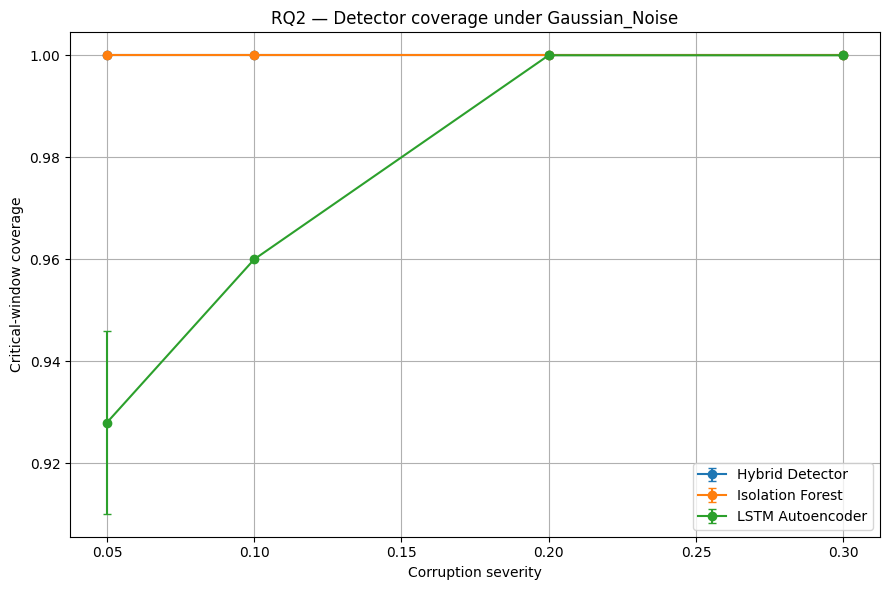

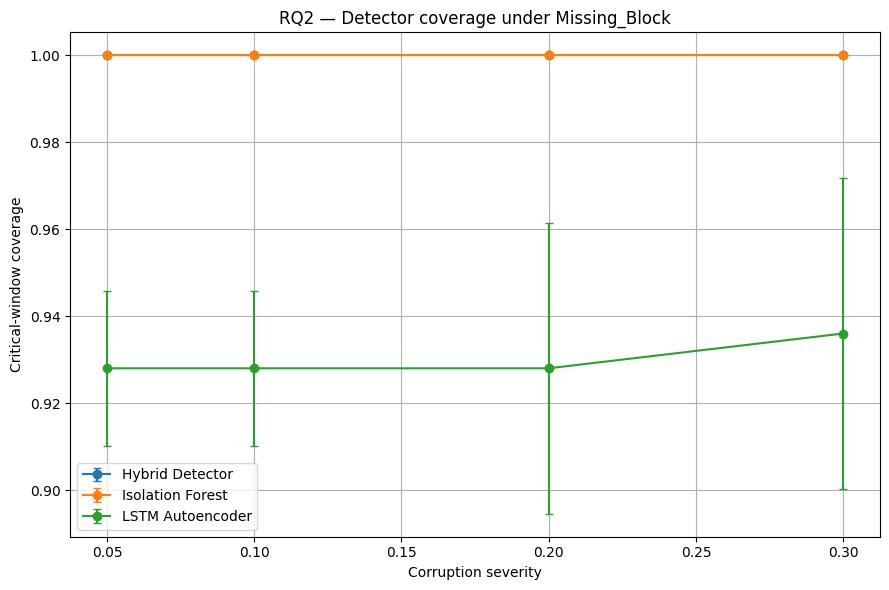

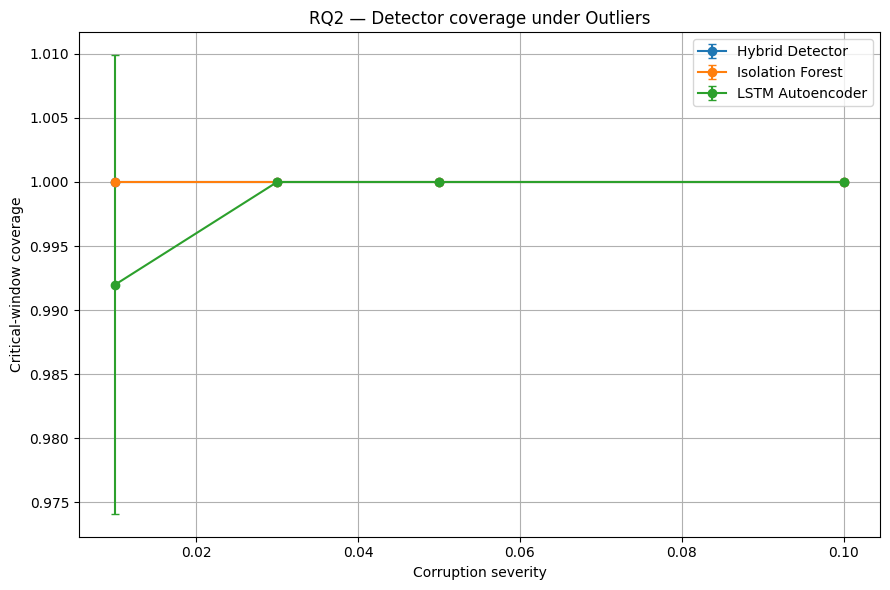

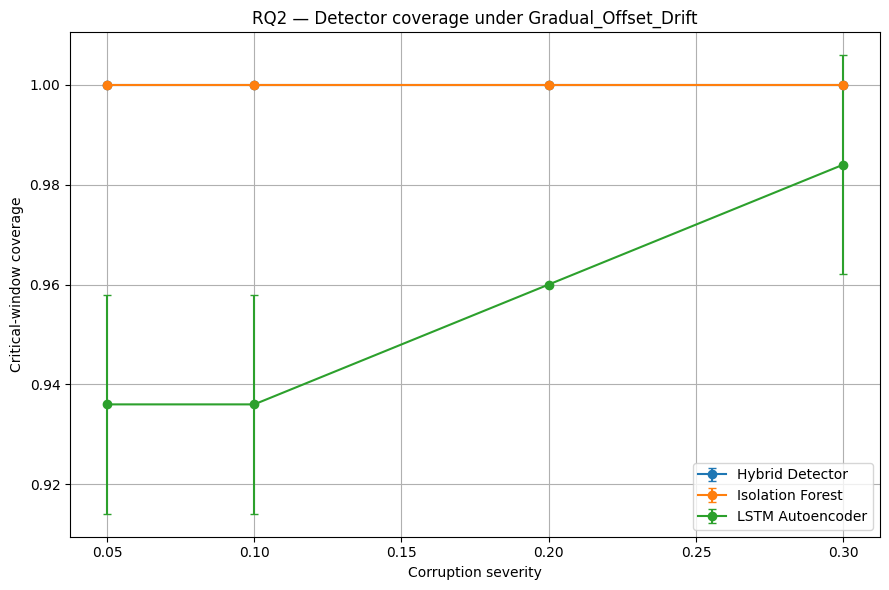

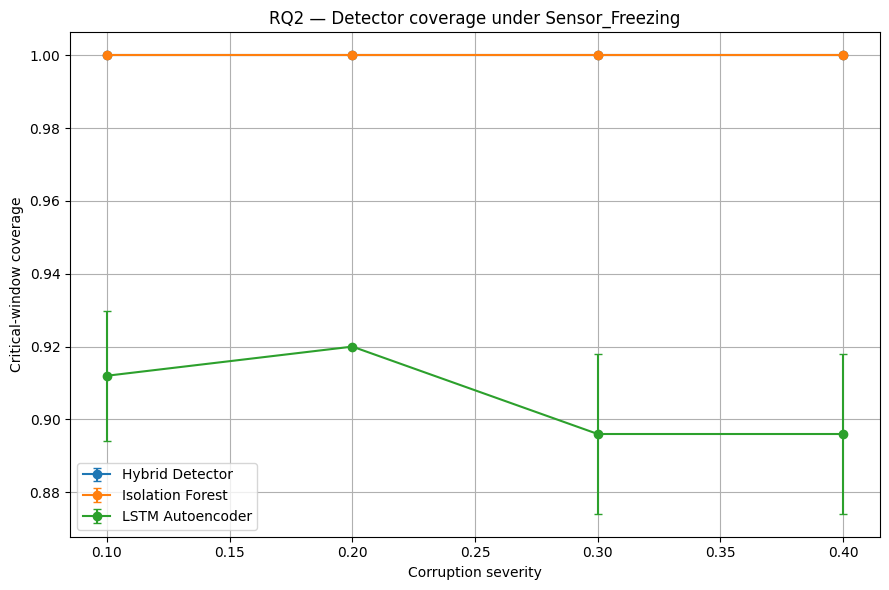

In [ ]:
for condition in CORRUPTION_LEVELS:
    plt.figure(figsize=(9, 6))

    # Subset robustness table for this corruption type
    subset = detector_robustness_by_level[
        detector_robustness_by_level["Condition"] == condition
    ]

    # Plot each detector's coverage curve
    for detector_name, group in subset.groupby("Detector"):
        group = group.sort_values("Level")

        plt.errorbar(
            group["Level"],
            group["Critical_Coverage"],
            yerr=group["Critical_Coverage_Std"],
            marker="o",
            capsize=3,
            label=detector_name,
        )

    plt.xlabel("Corruption severity")
    plt.ylabel("Critical-window coverage")
    plt.title(f"RQ2 — Detector coverage under {condition}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    # Save figure
    plt.savefig(
        FIG / (
            "rq2_detector_"
            + condition.lower()
            + "_coverage.png"
        ),
        dpi=300,
    )

    plt.show()

## RQ3 - Pipeline-Level Pareto Filtering

This section extends the Pareto‑efficiency methodology from Notebook 4 to the
pipeline‑level evaluation in Notebook 5.

The goal is to identify **non‑dominated pipeline configurations** across multiple
objectives relevant to deployment:

- **RMSE** (minimise)  
- **Missed-Critical Rate** (minimise)  
- **Invocation Reduction** (maximise)  
- **Estimated Median Latency** (minimise)  
- **Composite Detector Robustness** (maximise)  

The process has three stages:

#### **Merge pipeline metrics with detector robustness**
Each pipeline configuration (always‑on, gated, gated+periodic) is enriched with
detector‑level composite robustness metrics.

Always‑on inference has no detector, so its robustness values are set to **1.0**.

#### **Define pipeline objectives**
Each objective is assigned a direction (“min” or “max”).

#### **Pareto filtering**
A pipeline is Pareto‑efficient if **no other pipeline is strictly better across all
objectives**.  
This identifies the **non‑dominated frontier** of feasible deployment options.

The result is saved to:
10_pipeline_pareto_summary.csv.

This section provides the first half of RQ3’s final decision rule.  
TOPSIS ranking (Section 12) will refine the selection among Pareto‑efficient pipelines.


In [ ]:
# Merge pipeline results with detector composite robustness
pipeline_decision_table = (
    pipeline_results
    .merge(
        detector_composite_robustness,
        on="Detector",
        how="left",
    )
)

# Always-on inference has no detector → assign neutral robustness = 1.0
always_on_mask = (pipeline_decision_table["Detector"] == "None")

pipeline_decision_table.loc[always_on_mask, "Composite_Detector_Robustness"] = 1.0
pipeline_decision_table.loc[always_on_mask, "Composite_Detector_F1_Robustness"] = 1.0
pipeline_decision_table.loc[always_on_mask, "Worst_Condition_Coverage_Retention"] = 1.0

# Define pipeline objectives
PIPELINE_OBJECTIVES = {
    "RMSE": "min",
    "Missed_Critical_Rate": "min",
    "Invocation_Reduction": "max",
    "Estimated_Median_Total_Latency_s": "min",
    "Composite_Detector_Robustness": "max",
}

# Pareto dominance function
def dominates(row_a, row_b, objectives=PIPELINE_OBJECTIVES):
    """
    Determine whether row_a Pareto-dominates row_b.
    Conditions:
        • row_a is no worse in all objectives
        • row_a is strictly better in at least one objective
    """
    no_worse = True
    strictly_better = False

    for column, direction in objectives.items():
        value_a = float(row_a[column])
        value_b = float(row_b[column])

        if direction == "max":
            if value_a < value_b:
                no_worse = False
                break
            if value_a > value_b:
                strictly_better = True

        elif direction == "min":
            if value_a > value_b:
                no_worse = False
                break
            if value_a < value_b:
                strictly_better = True

        else:
            raise ValueError(f"Unsupported objective direction: {direction}")

    return (no_worse and strictly_better)

# Pareto mask computation
def pareto_mask(dataframe, objectives=PIPELINE_OBJECTIVES):
    """
    Compute boolean mask indicating Pareto-efficient rows.
    """
    records = dataframe.reset_index(drop=True)
    efficient = np.ones(len(records), dtype=bool)

    for index_i in range(len(records)):
        if not efficient[index_i]:
            continue

        for index_j in range(len(records)):
            if (
                index_i != index_j
                and dominates(records.iloc[index_j], records.iloc[index_i], objectives)
            ):
                efficient[index_i] = False
                break

    return efficient

# Apply Pareto filtering
pipeline_decision_table["Pareto_Efficient"] = pareto_mask(pipeline_decision_table)

# Save Pareto summary
pipeline_decision_table.to_csv(
    OUT / "10_pipeline_pareto_summary.csv",
    index=False,
)

# Display sorted Pareto frontier
display(
    pipeline_decision_table.sort_values(
        ["Pareto_Efficient", "Missed_Critical_Rate", "RMSE"],
        ascending=[False, True, True],
    )
)

,Pipeline,Detector,Threshold,Periodic_Safeguard,RMSE,MAE,Trigger_Rate,Invocation_Reduction,Critical_Coverage,Missed_Critical_Rate,False_Trigger_Rate,Detector_Penalty,Estimated_Median_Total_Latency_s,Estimated_P95_Total_Latency_s,Composite_Detector_Robustness,Composite_Detector_F1_Robustness,Mean_Detector_Penalty_Inflation_AUC,Worst_Condition_Coverage_Retention,Pareto_Efficient
0,Always-on RUL inference,None,NaN,NaN,12.143886,9.107116,1.00,0.00,1.00,0.00,1.000000,75.0,0.001505,0.001603,1.00000,1.000000,NaN,1.000000,True
2,Isolation Forest gate + periodic 5,Isolation Forest,0.531930,5.0,27.284685,18.048068,0.43,0.57,1.00,0.00,0.240000,18.0,0.028157,0.032884,1.00000,0.894846,2.361958,1.000000,True
3,Isolation Forest gate + periodic 10,Isolation Forest,0.531930,10.0,27.918593,18.718113,0.38,0.62,1.00,0.00,0.173333,13.0,0.028498,0.035909,1.00000,0.894846,2.361958,1.000000,True
4,Isolation Forest gate + periodic 20,Isolation Forest,0.531930,20.0,28.042527,18.948667,0.35,0.65,1.00,0.00,0.133333,10.0,0.043336,0.063307,1.00000,0.894846,2.361958,1.000000,True
1,Isolation Forest gate,Isolation Forest,0.531930,NaN,28.879167,19.685305,0.33,0.67,1.00,0.00,0.106667,8.0,0.028354,0.033071,1.00000,0.894846,2.361958,1.000000,True
6,LSTM Autoencoder gate + periodic 5,LSTM Autoencoder,0.330178,5.0,31.682814,20.210377,0.57,0.43,0.92,0.08,0.453333,74.0,0.095229,0.103528,1.03358,0.900440,0.970761,0.973913,True
7,LSTM Autoencoder gate + periodic 10,LSTM Autoencoder,0.330178,10.0,33.177607,21.741156,0.53,0.47,0.92,0.08,0.400000,70.0,0.095402,0.119231,1.03358,0.900440,0.970761,0.973913,True
8,LSTM Autoencoder gate + periodic 20,LSTM Autoencoder,0.330178,20.0,33.275084,21.919650,0.51,0.49,0.92,0.08,0.373333,68.0,0.130654,0.207776,1.03358,0.900440,0.970761,0.973913,True
5,LSTM Autoencoder gate,LSTM Autoencoder,0.330178,NaN,33.299681,22.026739,0.50,0.50,0.92,0.08,0.360000,67.0,0.099409,0.145117,1.03358,0.900440,0.970761,0.973913,True
10,Hybrid Detector gate + periodic 5,Hybrid Detector,2.192263,5.0,28.262876,18.597003,0.45,0.55,1.00,0.00,0.266667,20.0,0.127254,0.149406,1.00000,0.890444,2.381481,1.000000,False


## RQ3 - Constraint-Aware TOPSIS Ranking

This section completes the RQ3 decision-making process by applying:

1. **Constraint filtering**  
   Each deployment scenario defines minimum safety requirements:
   - maximum missed-critical rate  
   - minimum critical coverage  

   Only pipelines satisfying these constraints are considered feasible.

2. **Pareto filtering within feasible pipelines**  
   Among feasible pipelines, only Pareto-efficient ones are passed to TOPSIS.

3. **TOPSIS ranking**  
   TOPSIS ranks Pareto-efficient pipelines using:
   - min–max normalisation  
   - weighted objective scoring  
   - closeness to the ideal solution  

   Each scenario defines its own weighting scheme:
   - **Safety-Focused**  
   - **Balanced-Deployment**  
   - **Resource-Saving**

4. **Final recommendation**  
   For each scenario, the pipeline with the highest TOPSIS closeness is selected.


In [ ]:
# Constraint filtering
def apply_constraints(dataframe, constraints):
    """
    Apply scenario constraints:
        • column >= threshold
        • column <= threshold
    """
    mask = np.ones(len(dataframe), dtype=bool)

    for column, (operator, threshold) in constraints.items():
        if operator == ">=":
            mask &= (dataframe[column] >= threshold).to_numpy()
        elif operator == "<=":
            mask &= (dataframe[column] <= threshold).to_numpy()
        else:
            raise ValueError(f"Unsupported operator: {operator}")

    return dataframe[mask].copy()

# Min–max normalisation helpers
def minmax_benefit(series):
    """
    Normalise benefit-type metrics:
        higher = better
    """
    series = pd.Series(series, dtype=float)
    minimum = series.min()
    maximum = series.max()

    if np.isclose(minimum, maximum):
        return pd.Series(np.ones(len(series)), index=series.index)

    return (series - minimum) / (maximum - minimum)

def minmax_cost(series):
    """
    Normalise cost-type metrics:
        lower = better
    """
    return 1.0 - minmax_benefit(series)

# TOPSIS ranking
def minmax_topsis(dataframe, weights, objectives=PIPELINE_OBJECTIVES):
    """
    Apply min–max TOPSIS ranking to Pareto-efficient pipelines.
    """
    if dataframe.empty:
        return None, pd.DataFrame()

    # Normalise each objective
    normalised = pd.DataFrame(index=dataframe.index)

    for column, direction in objectives.items():
        normalised[column] = (
            minmax_benefit(dataframe[column])
            if direction == "max"
            else minmax_cost(dataframe[column])
        )

    # Weight vector
    weight_vector = np.asarray(
        [weights[column] for column in objectives],
        dtype=float,
    )
    weight_vector = weight_vector / weight_vector.sum()

    # Weighted matrix
    weighted = (
        normalised[list(objectives)].to_numpy()
        * weight_vector
    )

    # Ideal and anti-ideal points
    ideal = weighted.max(axis=0)
    anti_ideal = weighted.min(axis=0)

    # Distances
    distance_ideal = np.sqrt(((weighted - ideal) ** 2).sum(axis=1))
    distance_anti = np.sqrt(((weighted - anti_ideal) ** 2).sum(axis=1))

    # Closeness score
    closeness = np.divide(
        distance_anti,
        distance_ideal + distance_anti,
        out=np.ones_like(distance_anti),
        where=(distance_ideal + distance_anti > 1e-12),
    )

    result = dataframe.copy()
    result["TOPSIS_Closeness"] = closeness
    result["TOPSIS_Rank"] = (
        result["TOPSIS_Closeness"]
        .rank(ascending=False, method="min")
        .astype(int)
    )

    result = result.sort_values(
        ["TOPSIS_Rank", "Missed_Critical_Rate", "RMSE"],
        ascending=[True, True, True],
    )

    return result.iloc[0], result

# Scenario definitions
scenario_definitions = {
    "Safety_Focused": {
        "constraints": {
            "Missed_Critical_Rate": ("<=", 0.05),
            "Critical_Coverage": (">=", 0.95),
        },
        "weights": {
            "RMSE": 0.20,
            "Missed_Critical_Rate": 0.40,
            "Invocation_Reduction": 0.10,
            "Estimated_Median_Total_Latency_s": 0.10,
            "Composite_Detector_Robustness": 0.20,
        },
    },
    "Balanced_Deployment": {
        "constraints": {
            "Missed_Critical_Rate": ("<=", 0.15),
            "Critical_Coverage": (">=", 0.85),
        },
        "weights": {
            "RMSE": 0.25,
            "Missed_Critical_Rate": 0.25,
            "Invocation_Reduction": 0.20,
            "Estimated_Median_Total_Latency_s": 0.15,
            "Composite_Detector_Robustness": 0.15,
        },
    },
    "Resource_Saving": {
        "constraints": {
            "Missed_Critical_Rate": ("<=", 0.25),
            "Critical_Coverage": (">=", 0.75),
        },
        "weights": {
            "RMSE": 0.15,
            "Missed_Critical_Rate": 0.20,
            "Invocation_Reduction": 0.35,
            "Estimated_Median_Total_Latency_s": 0.20,
            "Composite_Detector_Robustness": 0.10,
        },
    },
}

# Apply scenario evaluation
scenario_rows = []
scenario_rankings = []

for scenario_name, definition in scenario_definitions.items():

    # Apply constraints
    feasible = apply_constraints(
        pipeline_decision_table,
        definition["constraints"],
    )

    # No feasible pipelines
    if feasible.empty:
        scenario_rows.append({
            "Scenario": scenario_name,
            "Status": "No feasible solution",
            "N_Feasible": 0,
        })
        continue

    # Pareto filtering within feasible set
    feasible["Pareto_Efficient_Within_Feasible_Set"] = pareto_mask(feasible)
    feasible_pareto = feasible[
        feasible["Pareto_Efficient_Within_Feasible_Set"]
    ].copy()

    # TOPSIS ranking
    winner, ranking = minmax_topsis(
        feasible_pareto,
        definition["weights"],
    )

    ranking.insert(0, "Scenario", scenario_name)
    scenario_rankings.append(ranking)

    # Store scenario summary
    scenario_rows.append({
        "Scenario": scenario_name,
        "Status": "Feasible",
        "N_Feasible": len(feasible),
        "N_Pareto": len(feasible_pareto),
        "Recommended_Pipeline": winner["Pipeline"],
        "RMSE": winner["RMSE"],
        "Missed_Critical_Rate": winner["Missed_Critical_Rate"],
        "Critical_Coverage": winner["Critical_Coverage"],
        "Invocation_Reduction": winner["Invocation_Reduction"],
        "Estimated_Median_Total_Latency_s": winner["Estimated_Median_Total_Latency_s"],
        "Composite_Detector_Robustness": winner["Composite_Detector_Robustness"],
        "TOPSIS_Closeness": winner["TOPSIS_Closeness"],
    })

# Save scenario recommendations
scenario_recommendations = pd.DataFrame(scenario_rows)

scenario_recommendations.to_csv(
    OUT / "11_scenario_recommendations.csv",
    index=False,
)

if scenario_rankings:
    pd.concat(
        scenario_rankings,
        ignore_index=True,
    ).to_csv(
        OUT / "11b_scenario_rankings.csv",
        index=False,
    )

display(scenario_recommendations)

,Scenario,Status,N_Feasible,N_Pareto,Recommended_Pipeline,RMSE,Missed_Critical_Rate,Critical_Coverage,Invocation_Reduction,Estimated_Median_Total_Latency_s,Composite_Detector_Robustness,TOPSIS_Closeness
0,Safety_Focused,Feasible,9,5,Always-on RUL inference,12.143886,0.0,1.0,0.00,0.001505,1.0,0.690983
1,Balanced_Deployment,Feasible,13,9,Always-on RUL inference,12.143886,0.0,1.0,0.00,0.001505,1.0,0.605714
2,Resource_Saving,Feasible,13,9,Isolation Forest gate,28.879167,0.0,1.0,0.67,0.028354,1.0,0.729958


In [ ]:
# Trigger Audit Table
# Produce per-window audit of detector behaviour
# Include detector score, threshold, trigger flag, critical flag

audit_rows = []

# Iterate over detectors
for detector_name, scores in detector_score_map_test.items():
    threshold = selected_thresholds[detector_name]

    # Trigger mask for this detector
    trigger = (scores >= threshold)

    # Per-window audit
    for index in range(len(yte)):
        audit_rows.append({
            "Detector": detector_name,
            "Test_Index": index,
            "Unit": int(test_metadata.iloc[index]["unit"]),
            "Last_Observed_Cycle": int(test_metadata.iloc[index]["cycle"]),
            "True_RUL": float(yte[index]),
            "Detector_Score": float(scores[index]),
            "Threshold": float(threshold),
            "Triggered": bool(trigger[index]),
            "Critical_Window": bool(yte[index] <= CRITICAL_RUL_MAX),
            "Always_On_RUL_Prediction": float(always_on_prediction[index]),
        })

# Build audit table
trigger_audit = pd.DataFrame(audit_rows)

trigger_audit.to_csv(
    OUT / "12_trigger_audit_table.csv",
    index=False,
)

display(trigger_audit.head())

,Detector,Test_Index,Unit,Last_Observed_Cycle,True_RUL,Detector_Score,Threshold,Triggered,Critical_Window,Always_On_RUL_Prediction
0,Isolation Forest,0,1,31,112.0,0.437161,0.53193,False,False,114.291069
1,Isolation Forest,1,2,49,98.0,0.437627,0.53193,False,False,123.122849
2,Isolation Forest,2,3,126,69.0,0.531401,0.53193,False,False,41.127632
3,Isolation Forest,3,4,106,82.0,0.468340,0.53193,False,False,100.473907
4,Isolation Forest,4,5,98,91.0,0.466273,0.53193,False,False,98.112404


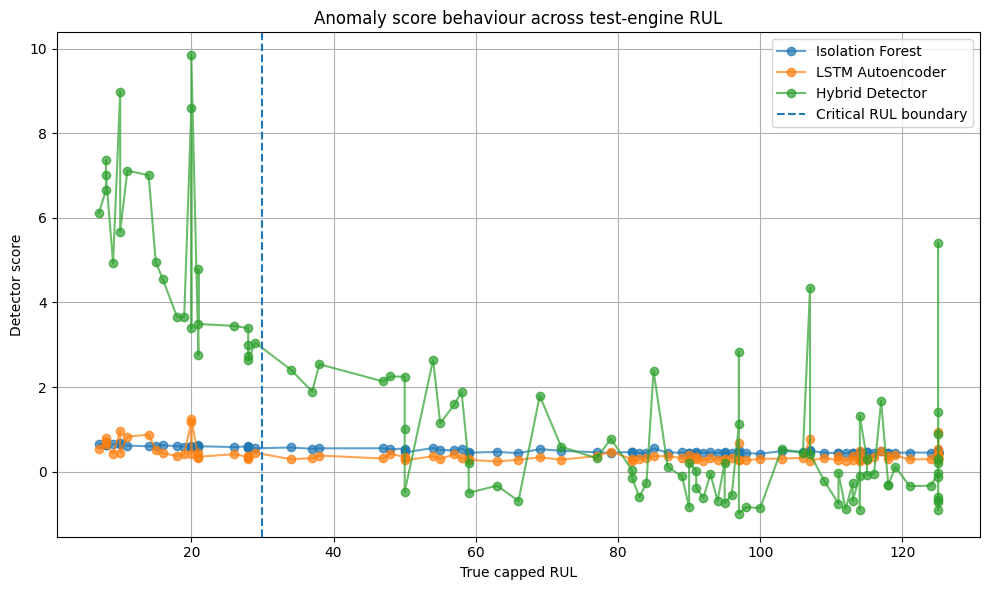

In [ ]:
# Detector Score Behaviour Across True RUL
# Plot anomaly scores vs true capped RUL for each detector
# Sort windows by true RUL for visual clarity

plt.figure(figsize=(10, 6))

# Plot each detector's anomaly score curve
for detector_name, scores in (detector_score_map_test.items()):

    # Sort test windows by true capped RUL
    order = np.argsort(yte)

    plt.plot(
        yte[order],
        scores[order],
        marker="o",
        alpha=0.7,
        label=detector_name,
    )

# Critical RUL boundary
plt.axvline(
    CRITICAL_RUL_MAX,
    linestyle="--",
    label="Critical RUL boundary",
)

plt.xlabel("True capped RUL")
plt.ylabel("Detector score")
plt.title("Anomaly score behaviour across test-engine RUL")

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIG / "detector_scores_vs_true_rul.png",
    dpi=300,
)

plt.show()

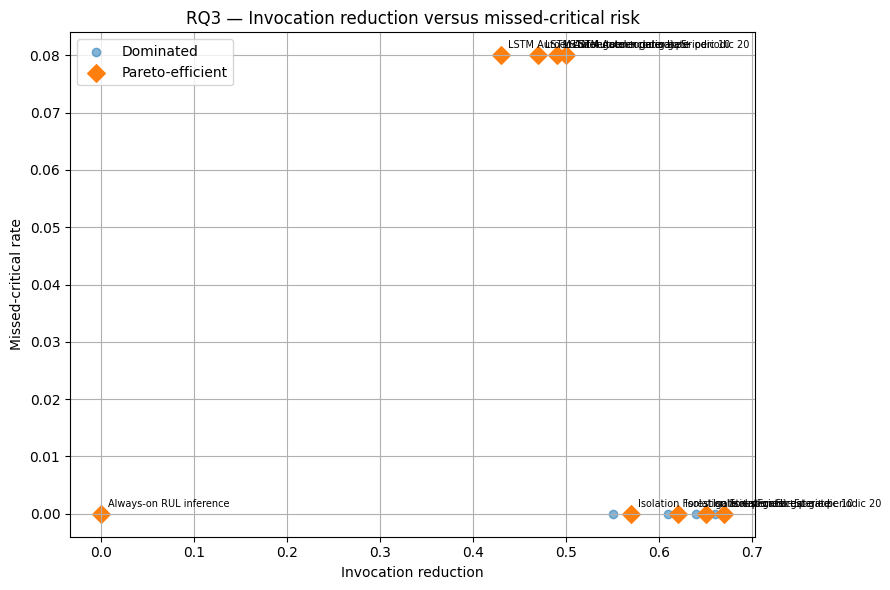

In [ ]:
# RQ3 Pareto Frontier Visualisation
# Plot dominated vs Pareto-efficient pipelines
# Visualise trade-off between invocation reduction and missed-critical risk
# Annotate Pareto-efficient pipelines

# Split pipelines into Pareto-efficient and dominated sets
pareto_front = pipeline_decision_table[
    pipeline_decision_table["Pareto_Efficient"]
]

dominated = pipeline_decision_table[
    ~pipeline_decision_table["Pareto_Efficient"]
]

plt.figure(figsize=(9, 6))

# Plot dominated pipelines
plt.scatter(
    dominated["Invocation_Reduction"],
    dominated["Missed_Critical_Rate"],
    alpha=0.55,
    label="Dominated",
)

# Plot Pareto-efficient pipelines
plt.scatter(
    pareto_front["Invocation_Reduction"],
    pareto_front["Missed_Critical_Rate"],
    marker="D",
    s=80,
    label="Pareto-efficient",
)

# Annotate Pareto-efficient pipelines
for _, row in pareto_front.iterrows():
    plt.annotate(
        row["Pipeline"],
        (
            row["Invocation_Reduction"],
            row["Missed_Critical_Rate"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=7,
    )

plt.xlabel("Invocation reduction")
plt.ylabel("Missed-critical rate")
plt.title("RQ3 — Invocation reduction versus missed-critical risk")

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIG / "rq3_invocation_reduction_vs_missed_critical.png",
    dpi=300,
)

plt.show()

## Notebook 5 Summary

In [ ]:
# Best detector by composite robustness
best_detector_row = (
    detector_composite_robustness
    .sort_values(
        ["Composite_Detector_Robustness",
         "Worst_Condition_Coverage_Retention"],
        ascending=[False, False],
    )
    .iloc[0]
)

# Final recommended pipeline
balanced_recommendation = scenario_recommendations[
    scenario_recommendations["Scenario"] == "Balanced_Deployment"
]

if (
    not balanced_recommendation.empty
    and balanced_recommendation.iloc[0]["Status"] == "Feasible"
):
    final_recommended_pipeline = balanced_recommendation.iloc[0]["Recommended_Pipeline"]
else:
    final_recommended_pipeline = (
        pipeline_decision_table[pipeline_decision_table["Pareto_Efficient"]]
        .sort_values(
            ["Missed_Critical_Rate", "RMSE", "Invocation_Reduction"],
            ascending=[True, True, False],
        )
        .iloc[0]["Pipeline"]
    )

# Build framework report dictionary
framework_report = {
    "Research_Extension": (
        "Anomaly-triggered RUL inference for temporal "
        "predictive-maintenance deployment."
    ),

    "Downstream_RUL_Model": downstream_model_name,

    "Best_Detector_By_Composite_Robustness": best_detector_row["Detector"],
    "Best_Detector_Composite_Robustness": float(
        best_detector_row["Composite_Detector_Robustness"]
    ),

    "Final_Recommended_Pipeline": final_recommended_pipeline,

    "RQ1_Interpretation": (
        "Pipeline-level evaluation determines whether selective "
        "inference changes deployment suitability relative to "
        "always-on RUL prediction."
    ),

    "RQ2_Interpretation": (
        "Detector robustness is quantified across controlled "
        "noise, missing blocks, outliers, gradual drift and "
        "sensor freezing."
    ),

    "RQ3_Interpretation": (
        "Selection uses feasibility constraints, Pareto filtering "
        "and adapted min-max TOPSIS."
    ),

    "Scenario_Recommendations": scenario_recommendations.to_dict(orient="records"),

    "Threshold_Selection_Method": (
        "Validation-only minimisation of false-trigger plus "
        "20-times missed-critical penalty."
    ),

    "Statistical_Validation": (
        "Engine-level bootstrap confidence intervals and paired "
        "Wilcoxon absolute-error comparisons with Holm correction."
    ),

    "Important_Limitations": [
        "FD001 contains one fault mode and one operating condition.",
        "The anomaly stage triggers RUL inference rather than multi-class fault diagnosis.",
        "Critical and warning RUL boundaries are study-defined.",
        "Penalty values and scenario constraints are assumed experimental parameters.",
        "The test set contains one final window per engine.",
    ],
}

# Save JSON report
with open(
    OUT / "13_framework_report.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(framework_report, file, indent=2)

# Display preview table
display(
    pd.DataFrame({
        "Item": list(framework_report.keys()),
        "Value": [str(value) for value in framework_report.values()],
    })
)

,Item,Value
0,Research_Extension,Anomaly-triggered RUL inference for temporal p...
1,Downstream_RUL_Model,XGBoost
2,Best_Detector_By_Composite_Robustness,LSTM Autoencoder
3,Best_Detector_Composite_Robustness,1.0335797101449276
4,Final_Recommended_Pipeline,Always-on RUL inference
5,RQ1_Interpretation,Pipeline-level evaluation determines whether s...
6,RQ2_Interpretation,Detector robustness is quantified across contr...
7,RQ3_Interpretation,"Selection uses feasibility constraints, Pareto..."
8,Scenario_Recommendations,"[{'Scenario': 'Safety_Focused', 'Status': 'Fea..."
9,Threshold_Selection_Method,Validation-only minimisation of false-trigger ...


## Final interpretation

This notebook provides a complete research-grade anomaly-triggered extension:

- detectors are trained only on healthy windows;
- thresholds are selected only on validation trajectories;
- always-on and gated RUL pipelines are compared on held-out engines;
- critical coverage, missed-critical risk, invocation reduction and latency are evaluated jointly;
- bootstrap and paired statistical analyses quantify uncertainty and paired error differences;
- temporal corruptions test detector robustness;
- Pareto filtering and constraint-aware TOPSIS provide a final deployment decision process.

The strongest defensible thesis claim is not that anomaly detection automatically improves every metric. It is:

> An anomaly-triggered pipeline can be evaluated as a configurable deployment mechanism that trades downstream invocation reduction against critical-failure coverage, RUL error, latency and robustness, with transparent feasibility and preference controls.